In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("train_time_series.csv")
df.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [4]:
df.describe(include=object)

,date,family
count,3000888,3000888
unique,1684,33
top,2017-08-15,AUTOMOTIVE
freq,1782,90936


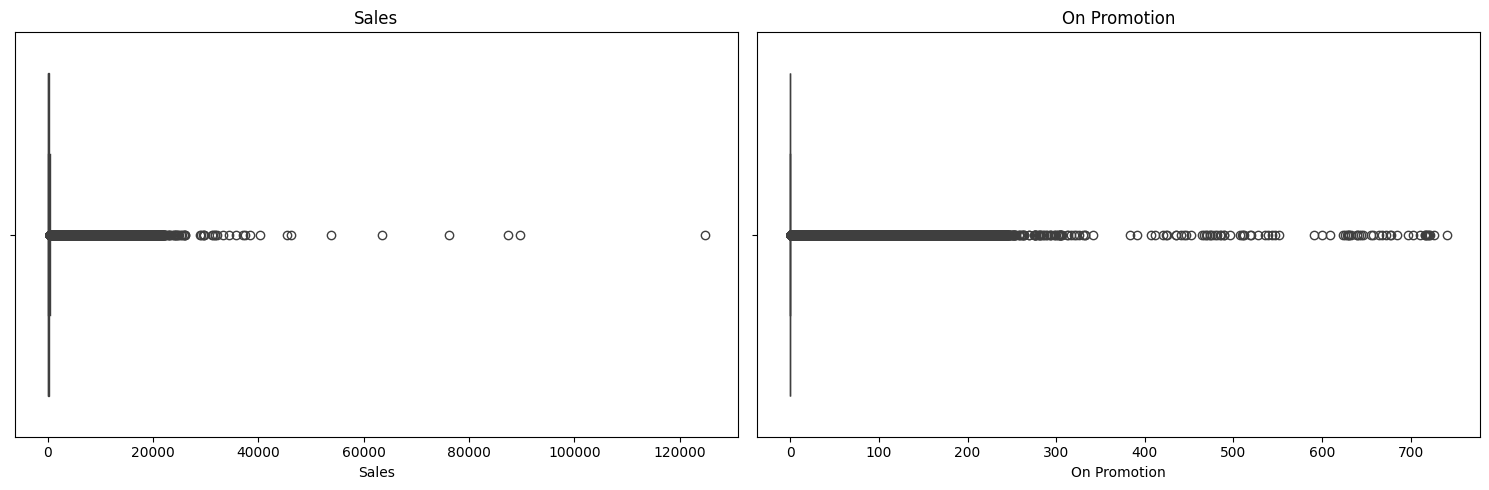

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['sales'], ax=axes[0])
axes[0].set_title('Sales')
axes[0].set_xlabel('Sales')
sns.boxplot(x=df['onpromotion'], ax=axes[1])
axes[1].set_title('On Promotion')
axes[1].set_xlabel('On Promotion')
plt.tight_layout()
plt.show()

C:\Users\borga\AppData\Local\Temp\ipykernel_9396\545616543.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sales'].fillna(method='ffill', inplace=True)
C:\Users\borga\AppData\Local\Temp\ipykernel_9396\545616543.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['sales'].fillna(method='ffill', inplace=True)


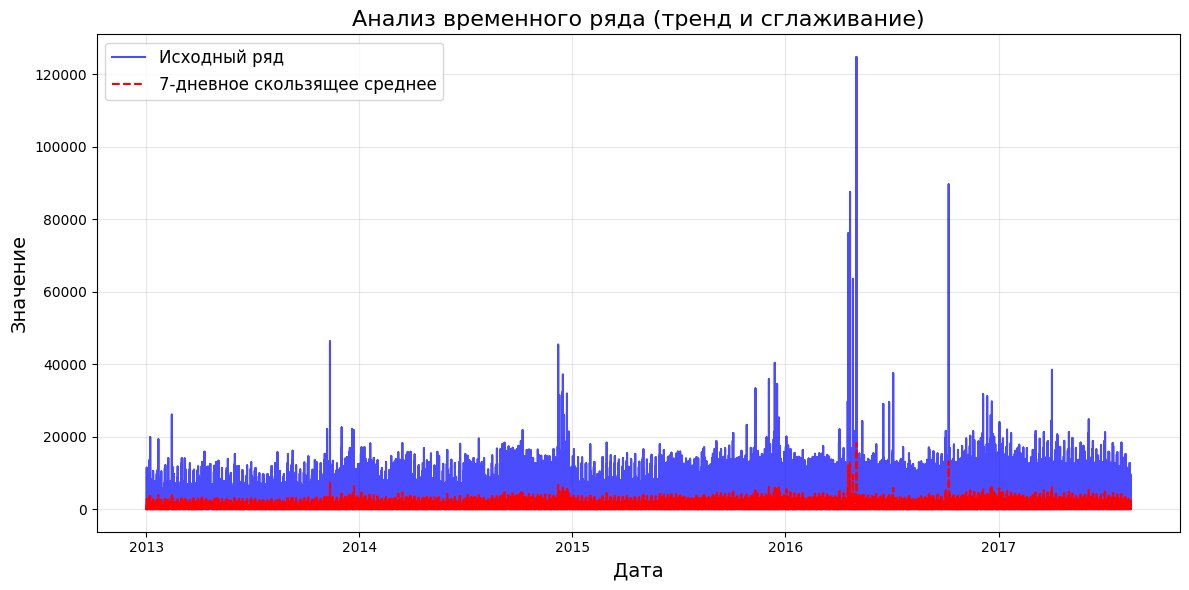

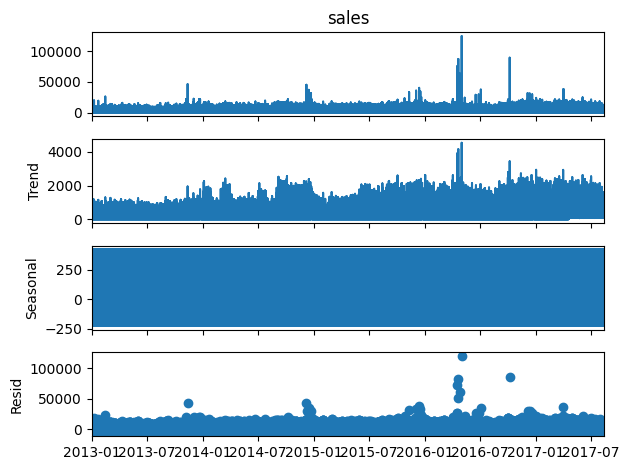

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'].fillna(method='ffill', inplace=True)
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'], label='Исходный ряд', color='blue', alpha=0.7)
plt.plot(df.index, df['rolling_mean_7'], label='7-дневное скользящее среднее', color='red', linestyle='--')
plt.title("Анализ временного ряда (тренд и сглаживание)", fontsize=16)
plt.xlabel("Дата", fontsize=14)
plt.ylabel("Значение", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

decomposition = seasonal_decompose(df['sales'], model='additive', period=30)
decomposition.plot()
plt.show()

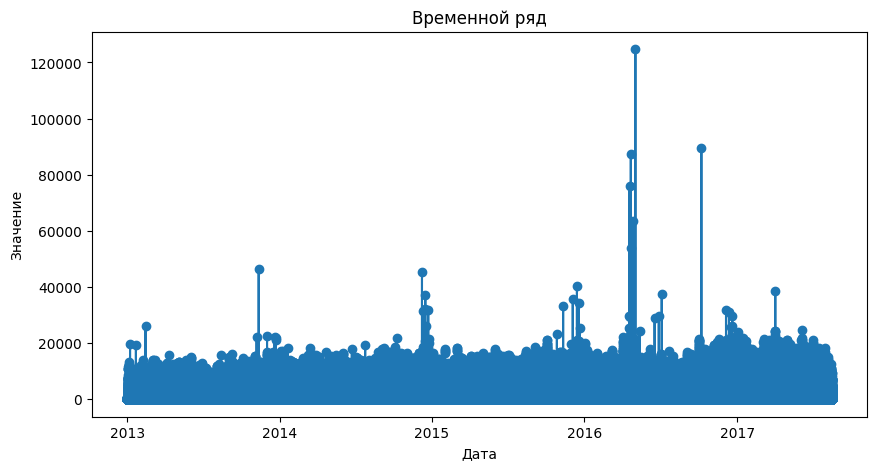

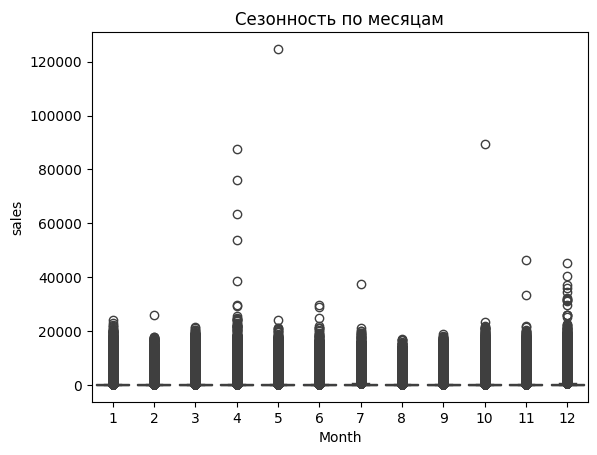

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['sales'], marker='o')
plt.title("Временной ряд")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.show()
df['Month'] = df.index.month
sns.boxplot(x='Month', y='sales', data=df)
plt.title("Сезонность по месяцам")
plt.show()

In [ ]:
def remove_empty_columns(table):
    if not table:
        return []
    transposed = list(zip(*table))
    filtered = [col for col in transposed if any(
        cell is not None for cell in col)]
    return [list(row) for row in zip(*filtered)] if filtered else []


def remove_duplicates(table):
    seen = set()
    unique = []
    for row in table:
        key = tuple(row)
        if key not in seen:
            seen.add(key)
            unique.append(row)
    return unique


def process_email(email):
    if not email:
        return None
    email = email.replace('[at]', '@')
    return email.split('@')[-1]


def process_status(status):
    return 'Выполнено' if status \
        and status.lower() == 'да' else status


def process_name(full_name):
    if not full_name:
        return None
    parts = full_name.split()
    if len(parts) < 3:
        return full_name
    first = parts[0][0]
    middle_part = parts[1].rstrip('.')
    middle = middle_part[0] if middle_part else ''
    last = ' '.join(parts[2:])
    return f"{first}.{middle}. {last}"


def process_date(date_str):
    if not date_str:
        return None
    parts = date_str.split('.')
    if len(parts) != 3:
        return date_str
    year, month, day = parts
    return f"{day.zfill(2)}-{month.zfill(2)}-{year[-2:]}"


def transform_row(row):
    return [
        process_email(row[0]),
        process_status(row[1]),
        process_name(row[2]),
        process_date(row[3])
    ]


def sort_table(table):
    return sorted(table, key=lambda x: x[3] or '')


def main(input_table):
    table = remove_empty_columns(input_table)
    table = remove_duplicates(table)
    transformed = [transform_row(row) for row in table]
    return sort_table(transformed)